<a href="https://colab.research.google.com/github/ritikaparate17/Obesity-Analysis-/blob/main/EDA_ObesityPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Libraries**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
import warnings
warnings.filterwarnings('ignore')

**Load Data**

In [13]:
data = pd.read_csv("Obesity dataset.csv")#load data

**Data Cleaning**

In [14]:
data.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Male,39.2,1.49,79.2,no,yes,1,1,Always,no,2,no,0,2,Frequently,Automobile,Overweight_Level_II
1,Male,55.2,1.74,150.5,yes,no,3,1,Frequently,no,2,no,0,1,Frequently,Bike,Normal_Weight
2,Male,15.6,1.61,143.6,yes,yes,3,1,Sometimes,no,1,no,1,2,Sometimes,Automobile,Insufficient_Weight
3,Female,23.3,1.70,160.8,yes,yes,2,2,Frequently,no,2,no,0,2,Frequently,Walking,Obesity_Type_II
4,Female,59.3,1.87,60.9,no,yes,2,4,no,no,1,no,3,1,Sometimes,Public_Transportation,Overweight_Level_I


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   int64  
 7   NCP             2111 non-null   int64  
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   int64  
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   int64  
 13  TUE             2111 non-null   int64  
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(3), int64(5), object(9

**There are total 2111 entries. 17 columns,2111 rows. Age is in float but it should be in integer datatype.**

In [16]:
# Checking the missing values
data.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


**As we can see, there are no null values in any of the columns**

Age can't be like 21.0,. So,Converting Age column float datatype into integer datatype.

In [17]:
data['Age'] = data['Age'].apply(np.int64)

In [19]:
data.dtypes

,0
Gender,object
Age,int64
Height,float64
Weight,float64
family_history,object
FAVC,object
FCVC,int64
NCP,int64
CAEC,object
SMOKE,object


In [20]:
data.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Male,39,1.49,79.2,no,yes,1,1,Always,no,2,no,0,2,Frequently,Automobile,Overweight_Level_II
1,Male,55,1.74,150.5,yes,no,3,1,Frequently,no,2,no,0,1,Frequently,Bike,Normal_Weight
2,Male,15,1.61,143.6,yes,yes,3,1,Sometimes,no,1,no,1,2,Sometimes,Automobile,Insufficient_Weight
3,Female,23,1.70,160.8,yes,yes,2,2,Frequently,no,2,no,0,2,Frequently,Walking,Obesity_Type_II
4,Female,59,1.87,60.9,no,yes,2,4,no,no,1,no,3,1,Sometimes,Public_Transportation,Overweight_Level_I


**Obesity level column is in categorical form & it need to be converted into numeric.**

In [21]:
#Converting Obesity level column in numerical using encoding technique.
import pandas as pd
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
# Fit and transform the 'Obesity' column
data['obesity_level_encoded'] = label_encoder.fit_transform(data['Obesity'])

**Checking Duplicates**

In [22]:
# Check for duplicate rows
duplicate_rows = data[data.duplicated()]
print("Duplicate Rows:")
print(duplicate_rows)

Duplicate Rows:
      Gender  Age  Height  Weight family_history FAVC  FCVC  NCP        CAEC  \
69    Female   53    1.75   142.5             no  yes     1    2          no   
111     Male   15    1.58   135.4            yes  yes     2    3      Always   
220     Male   49    1.72    89.7            yes   no     2    1      Always   
262     Male   18    1.99   139.1            yes  yes     2    2  Frequently   
397     Male   29    1.66    79.4            yes   no     3    4  Frequently   
435     Male   36    1.52   165.5             no  yes     3    3   Sometimes   
606     Male   22    1.74   105.3            yes   no     1    2  Frequently   
671     Male   42    1.57   107.8             no   no     3    1   Sometimes   
691   Female   45    1.49    44.1            yes   no     3    2          no   
809   Female   23    1.91    56.1             no   no     1    1          no   
826   Female   45    1.68   142.5             no  yes     1    1  Frequently   
864   Female   46    1.9

**Removing duplicates**

In [23]:
data_cleaning = data.drop_duplicates()

**Earlier we had 2111 rows and now we have 2087 rows i.e. 24 duplicate rows were there which should be removed.**

In [24]:
data.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,obesity_level_encoded
0,Male,39,1.49,79.2,no,yes,1,1,Always,no,2,no,0,2,Frequently,Automobile,Overweight_Level_II,6
1,Male,55,1.74,150.5,yes,no,3,1,Frequently,no,2,no,0,1,Frequently,Bike,Normal_Weight,1
2,Male,15,1.61,143.6,yes,yes,3,1,Sometimes,no,1,no,1,2,Sometimes,Automobile,Insufficient_Weight,0
3,Female,23,1.70,160.8,yes,yes,2,2,Frequently,no,2,no,0,2,Frequently,Walking,Obesity_Type_II,3
4,Female,59,1.87,60.9,no,yes,2,4,no,no,1,no,3,1,Sometimes,Public_Transportation,Overweight_Level_I,5


In [25]:
data.dtypes

,0
Gender,object
Age,int64
Height,float64
Weight,float64
family_history,object
FAVC,object
FCVC,int64
NCP,int64
CAEC,object
SMOKE,object


In [26]:
data['Weight'] = data['Weight'].apply(np.int64)

In [27]:
data.dtypes

,0
Gender,object
Age,int64
Height,float64
Weight,int64
family_history,object
FAVC,object
FCVC,int64
NCP,int64
CAEC,object
SMOKE,object


In [28]:
data.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,obesity_level_encoded
0,Male,39,1.49,79,no,yes,1,1,Always,no,2,no,0,2,Frequently,Automobile,Overweight_Level_II,6
1,Male,55,1.74,150,yes,no,3,1,Frequently,no,2,no,0,1,Frequently,Bike,Normal_Weight,1
2,Male,15,1.61,143,yes,yes,3,1,Sometimes,no,1,no,1,2,Sometimes,Automobile,Insufficient_Weight,0
3,Female,23,1.70,160,yes,yes,2,2,Frequently,no,2,no,0,2,Frequently,Walking,Obesity_Type_II,3
4,Female,59,1.87,60,no,yes,2,4,no,no,1,no,3,1,Sometimes,Public_Transportation,Overweight_Level_I,5


**Done with data cleaning.**

**Columns:** **Gender,Age,Height,Weight,family_history**,**FAVC:** Frequent consumption of high-calorie food,**FCVC:** Frequency of consumption of vegetables,**NCP:** Nutrition Care Process,No. of main meals,**CAEC:** Consumption of food between meals,**Smoke** ,**CH2O** Consumption of daily water,**SCC:** Somatic Cell Count,Calories Consumption,**FAF:** Physical Activity Frequency,**TUE:** Time using technology devices,**CALC:** Alcohol Consumption,**MTRANS:** Means of Transportation,**Obesity**,**obesity_level_encoded**

**For better visualization Creating another column to define Age groups.**

In [29]:
def categorize_age(age):
    if age >= 60:
        return 'Senior'
    elif age >= 20:
        return 'Adult'
    elif age >= 13:
        return 'Teenager'
    else:
        return 'Child'

# create Age Group column
data['Age Group'] = data['Age'].apply(categorize_age)

In [30]:
data.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,obesity_level_encoded,Age Group
0,Male,39,1.49,79,no,yes,1,1,Always,no,2,no,0,2,Frequently,Automobile,Overweight_Level_II,6,Adult
1,Male,55,1.74,150,yes,no,3,1,Frequently,no,2,no,0,1,Frequently,Bike,Normal_Weight,1,Adult
2,Male,15,1.61,143,yes,yes,3,1,Sometimes,no,1,no,1,2,Sometimes,Automobile,Insufficient_Weight,0,Teenager
3,Female,23,1.70,160,yes,yes,2,2,Frequently,no,2,no,0,2,Frequently,Walking,Obesity_Type_II,3,Adult
4,Female,59,1.87,60,no,yes,2,4,no,no,1,no,3,1,Sometimes,Public_Transportation,Overweight_Level_I,5,Adult


**Now, We can compare the Gender based on Age groups having Obesity**

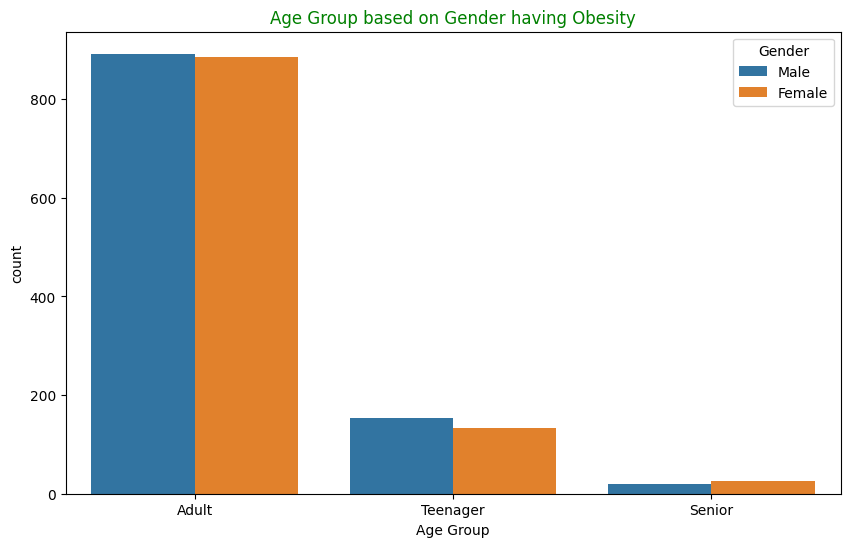

In [31]:
# Age Group based on Gender using bar plot
plt.figure(figsize=(10,6))
sns.countplot(data=data,x='Age Group',hue='Gender')
plt.title('Age Group based on Gender having Obesity',color='g')
plt.show()

**Here we can see,** 1. Adults are more suffering from this disease. 2. Adult males are more suffering than females. 3. Small ratio of teenagers. 4. No more seniors suffering.  5.Only 1 female from senior age group.

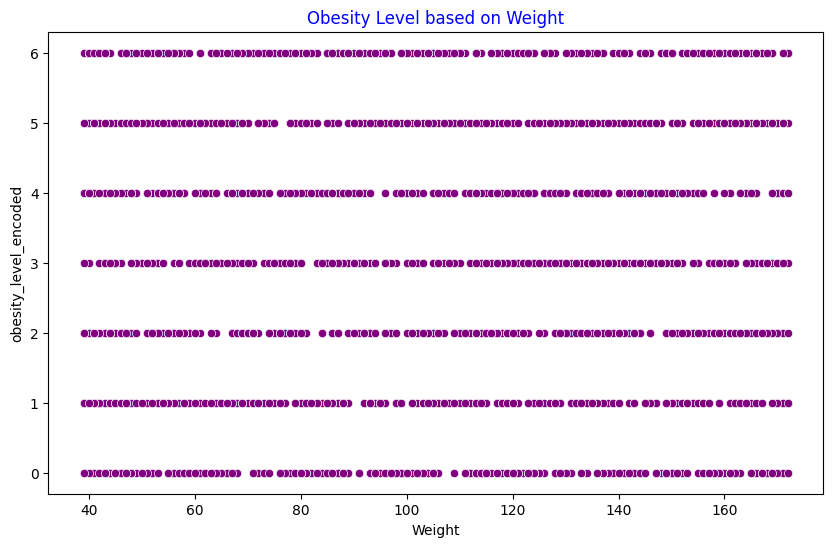

In [32]:
# Obesity Level based on Weight using scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=data,x='Weight',y='obesity_level_encoded',color='purple')
plt.title('Obesity Level based on Weight',color='b')
plt.show()

**Here we can see that,** 1. Obesity levels are represented as discrete categories (0–6), resulting in horizontal bands across the plot.

2. Weight values are distributed across all obesity categories, ranging approximately from 40 kg to 170 kg.
3. There is no strong visible trend or correlation between weight and obesity level in this visualization alone, as similar weight values appear across multiple obesity categories.
4. The overlap of points suggests that weight by itself is insufficient to determine obesity level accurately.

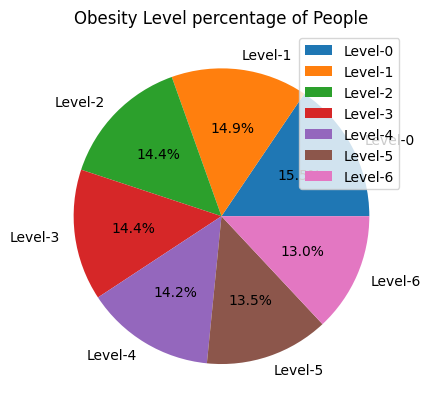

In [33]:
#plot pie chart based on obesity_level_encoded
obesity_counts = data['obesity_level_encoded'].value_counts()
labels=['Level-0','Level-1','Level-2','Level-3','Level-4','Level-5','Level-6',]
# Plot the pie chart
plt.pie(obesity_counts, labels=labels, autopct='%1.1f%%')
plt.title('Obesity Level percentage of People')
plt.legend()
plt.show()



**From above we can see that,** 1. Level-0 people are more i.e. highest 15% people belong. 2. Level-6 people are less i.e.lowest only 13% people belong.3. There are equal percentage of people belong to Level-2 & 3 i.e. 14.4% people.

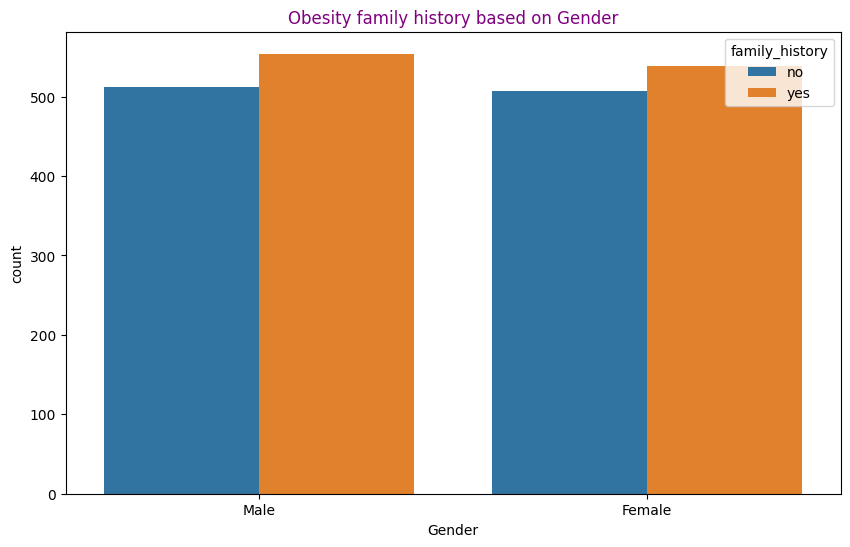

In [34]:
# Obesity family history based on Gender using bar plot
plt.figure(figsize=(10,6))
sns.countplot(data=data,x='Gender',hue='family_history')
plt.title('Obesity family history based on Gender',color='purple')
plt.show()

**From the above**, 1. There are more male than females who are suffering from the obestity. 2. The ratio of family members having obesity of both male and females are high. So, we can consider as most of the people are having obesity because of genetics.

# Summary
Adults are suffering more from these disease . Adult males are suffering more than females . Teenagers ratio is medium. Seniors are healthy as only few are having this disease. People having weight upto 70 are normal. People having weight between 50-110 are having highest obesity level. More people are in the starting phase of obesity & very less people are suffering from highest level of obesity. More ratio of family members having obesity i.e. It may happening because of genetics.

In [36]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.4 MB/s eta 0:00:00


In [39]:
from ydata_profiling import ProfileReport